# import torch

In [1]:
import torch
print('PyTorch:', torch.__version__) 
print('CUDA 사용 가능:', torch.cuda.is_available()) 
print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.31  Python-3.11.15 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Setup complete  (16 CPUs, 31.7 GB RAM, 156.6/475.9 GB disk)


In [3]:
import cv2
import roboflow
import inference_sdk

# 로보플로 인퍼런스 api 사용하기

In [4]:
from inference_sdk import InferenceHTTPClient

CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="7gVwRNptf2LzHT4H7n07"
)

result = CLIENT.infer('sample.jpg', model_id="rock-paper-scissors-sxsw/14")

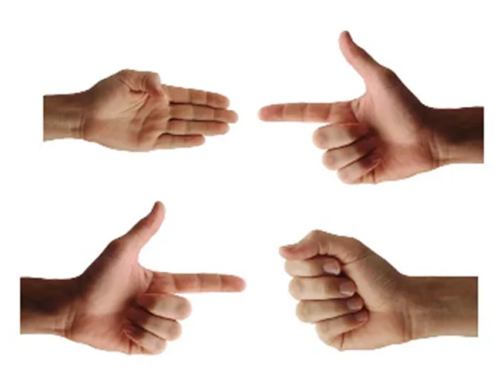

In [5]:
import matplotlib.pyplot as plt  # ← 추가

img = cv2.imread('sample.jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# CV2 

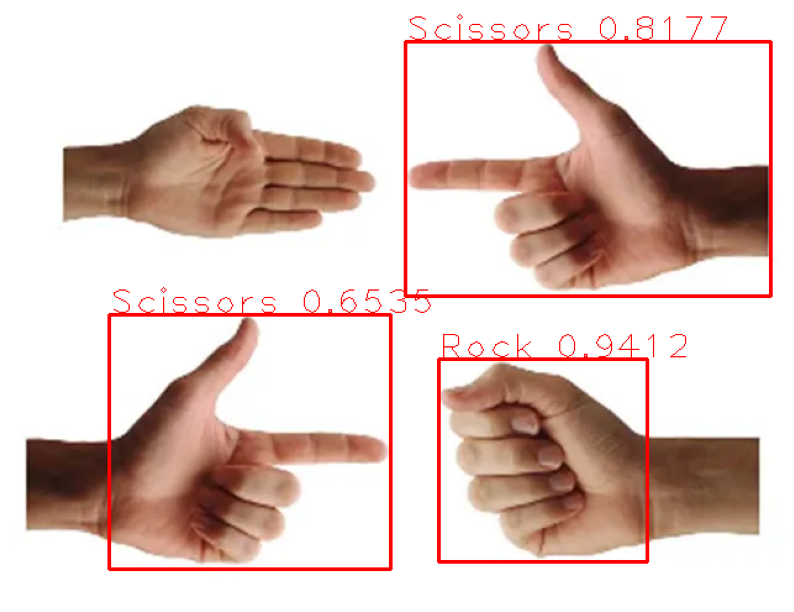

In [6]:
import cv2
import matplotlib.pyplot as plt

filename = 'sample.jpg'
result = CLIENT.infer(filename, model_id="rock-paper-scissors-sxsw/14")
img = cv2.imread(filename)

for pred in result["predictions"]:
    x, y = pred['x'], pred['y']
    width, height = pred['width'], pred['height']
    conf = pred['confidence']
    cls = pred['class']
    x1, y1 = int(x-width/2), int(y-height/2)
    x2, y2 = int(x+width/2), int(y+height/2)
    cv2.rectangle(img, (x1,y1), (x2, y2), (0,0,255), 2)
    cv2.putText(img, f'{cls} {conf:.4f}', (x1,y1), cv2.FONT_HERSHEY_PLAIN, 2, (0,0,255))

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# roboflow YOLOv8

In [7]:
from roboflow import Roboflow
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("ROBOFLOW_API_KEY")

In [8]:
# !pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key=roboflow_api)
project = rf.workspace("s-workspace-9zewk").project("Mnist_numbers")
dataset = project.version(1).download("yolov8")

NameError: name 'roboflow_api' is not defined

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="7gVwRNptf2LzHT4H7n07")
project = rf.workspace("s-workspace-9zewk").project("Mnist_numbers")
dataset = project.version(1).download("yolov8")

In [ ]:
# (Legacy) Serverless Hosted API

{% hint style="info" %}
We **recommend** using the V2 of our Serverless Hosted API. The V2 API is faster.\
\
[Refer to the Serverless Hosted API V2 documentation to get started with the new API.](https://docs.roboflow.com/deploy/serverless-hosted-api-v2)
{% endhint %}

## Model Support

The following models types are supported by the Serverless Hosted API (v1):

| Task Type                                                                                                        | Supported by Hosted API (v1) |
| ---------------------------------------------------------------------------------------------------------------- | ---------------------------- |
| [Object Detection](https://docs.roboflow.com/deploy/serverless/object-detection)                                 | ✅                            |
| [Classification](https://docs.roboflow.com/deploy/serverless/classification)                                     | ✅                            |
| [Instance Segmentation](https://docs.roboflow.com/deploy/serverless/instance-segmentation)                       | ✅                            |
| [Semantic Segmentation](https://docs.roboflow.com/deploy/serverless/instance-segmentation/semantic-segmentation) | ✅                            |
| [Keypoint Detection](https://docs.roboflow.com/deploy/serverless/keypoint-detection)                             | ✅                            |

## Latency comparison (v1 vs v2)

The end-to-end latency of requests sent to the Serverless Hosted API depends on several factors:

1. Model architecture, which has a bearing on the execution time
2. Size and resolution of the images that impact upload time and model inference time during execution
3. Network latency and bandwidth, which affects request upload time and response download time.
4. Service subscription and usage by other users at any specific time which could result in queueing latency

<figure><img src="https://662926385-files.gitbook.io/~/files/v0/b/gitbook-x-prod.appspot.com/o/spaces%2F-M6S9nPJhEX9FYH6clfW%2Fuploads%2FqMum7HkzyWoxLnOpbVGx%2Fserverless-img.png?alt=media&#x26;token=e075c90c-32a9-4691-9afc-54ec9831251b" alt=""><figcaption></figcaption></figure>

We show some representative benchmarks of v1 vs v2 Serverless Hosted API in the table below. It shows both the end-to-end latency (E2E) as well as the execution time (Exec). These numbers are for information only, we encourage users to perform their own benchmarks using [our inference benchmark tools](https://inference.roboflow.com/inference_helpers/cli_commands/benchmark/) or their own custom benchmarks.

<table><thead><tr><th width="176.14410400390625">Model</th><th>V2 (E2E)</th><th>V2 (Exec)</th><th>V1 (E2E)</th><th>V1 (Exec)</th></tr></thead><tbody><tr><td>yolov8x-640</td><td>401 ms</td><td>29 ms</td><td>4084 ms</td><td>821 ms</td></tr><tr><td>yolov8m-640</td><td>757 ms</td><td>21 ms</td><td>572 ms</td><td>265 ms</td></tr><tr><td>yolov8n-640</td><td>384 ms</td><td>17 ms</td><td>312 ms</td><td>63 ms</td></tr><tr><td>yolov8x-1280</td><td>483 ms</td><td>97 ms</td><td>6431 ms</td><td>3032 ms</td></tr><tr><td>yolov8m-1280</td><td>416 ms</td><td>52 ms</td><td>1841 ms</td><td>1006 ms</td></tr><tr><td>yolov8n-1280</td><td>428 ms</td><td>35 ms</td><td>464 ms</td><td>157 ms</td></tr></tbody></table>

We encourage users to run their own benchmarks for their model inferences and workflows to get real metrics on their specific usecases.

## Limits

The Serverless Hosted API (v1), regardless of the specific task type, accepts files up to 5MB. This limit includes, but is not limited to, the image file size plus any request information attached.

{% hint style="info" %}
In the cases that requests are too large, we recommend downsizing any attached images. This usually will not result in poor performance as images are downsized regardless after they've been received on our servers to the input size that the model architecture accepts.\
\
Some of our SDKs, like the Python SDK, automatically downsize images to the model architecture's input size before they are sent to the API.
{% endhint %}


# MNIST 숫자 탐지 - YOLOv8 로컬 학습

## 1단계: 데이터셋 확인

In [9]:
import yaml
import os
import glob
import cv2
import matplotlib.pyplot as plt

# data.yaml 확인
data_yaml_path = 'Mnist_numbers.v1i.yolov8/data.yaml'

with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("=== 데이터셋 설정 ===")
print(f"클래스 수: {data_config['nc']}")
print(f"클래스명: {data_config['names']}")
print(f"Train 경로: {data_config['train']}")
print(f"Val 경로: {data_config['val']}")
print(f"Test 경로: {data_config['test']}")

# 이미지 수 확인
for split in ['train', 'val', 'test']:
    img_path = data_config[split]
    imgs = glob.glob(os.path.join(img_path, '*.jpg'))
    print(f"\n{split}: {len(imgs)}장")

=== 데이터셋 설정 ===
클래스 수: 10
클래스명: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Train 경로: C:/Users/Admin/hipython/OBJDECT/Mnist_numbers.v1i.yolov8/train/images
Val 경로: C:/Users/Admin/hipython/OBJDECT/Mnist_numbers.v1i.yolov8/valid/images
Test 경로: C:/Users/Admin/hipython/OBJDECT/Mnist_numbers.v1i.yolov8/test/images

train: 12장

val: 2장

test: 2장


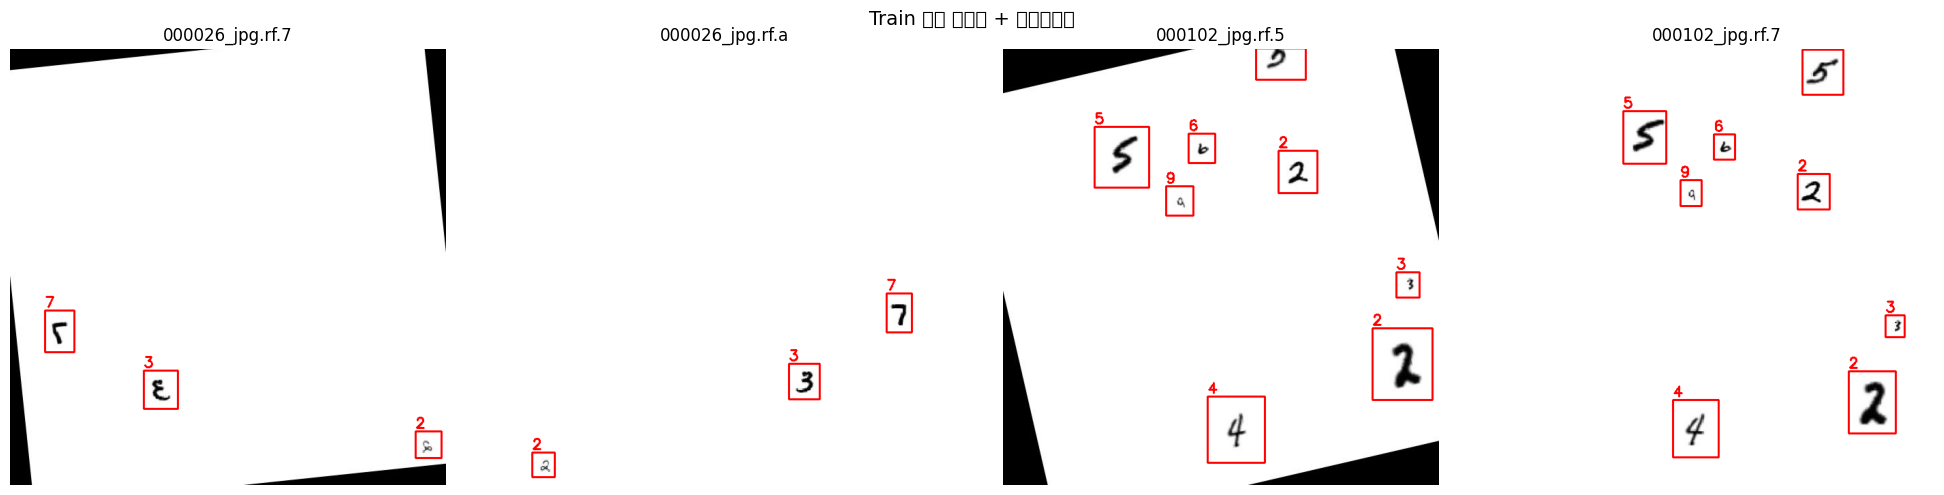

In [10]:
# 샘플 이미지 + 라벨 시각화
train_img_dir = data_config['train']
train_lbl_dir = train_img_dir.replace('images', 'labels')
class_names = data_config['names']

sample_imgs = glob.glob(os.path.join(train_img_dir, '*.jpg'))[:4]

fig, axes = plt.subplots(1, len(sample_imgs), figsize=(20, 5))
for i, img_path in enumerate(sample_imgs):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # 라벨 파일 읽기
    lbl_path = os.path.join(train_lbl_dir, os.path.basename(img_path).replace('.jpg', '.txt'))
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f.readlines():
                cls_id, cx, cy, bw, bh = map(float, line.strip().split())
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                cv2.putText(img, class_names[int(cls_id)], (x1, y1-5),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(os.path.basename(img_path)[:15])

plt.suptitle('Train 샘플 이미지 + 바운딩박스', fontsize=14)
plt.tight_layout()
plt.show()

## 2단계: YOLOv8 모델 학습 (Training)

In [11]:
from ultralytics import YOLO

# nano 모델 (가장 빠름)
model = YOLO("yolov8n.pt")

# 학습 실행
results = model.train(
    data="Mnist_numbers.v1i.yolov8/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="runs_numbers",
    name="mnist_exp1",
)


New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.31  Python-3.11.15 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Mnist_numbers.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_sc

In [12]:
from ultralytics import YOLO 
# 학습된 모델 로드
model = YOLO("C:/Users/Admin/runs/detect/runs/detect/mnist_numbers/weights/best.pt") 

# valid 이미지로 추론
filename = 'C:/Users/Admin/hipython/OBJDECT/Mnist_numbers.v1i.yolov8/valid/images/000855_jpg.rf.1b039f8da5bfce1e8417fcb8b5c9f4e1.jpg'
results = model.predict(source=filename, conf=0.25)

for result in results:
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = box.conf[0].item()
        cls_id = int(box.cls[0].item())
        print(f"클래스: {cls_id}, 신뢰도: {conf:.4f}, 좌표: ({x1}, {y1}), ({x2}, {y2})")



image 1/1 C:\Users\Admin\hipython\OBJDECT\Mnist_numbers.v1i.yolov8\valid\images\000855_jpg.rf.1b039f8da5bfce1e8417fcb8b5c9f4e1.jpg: 640x640 (no detections), 24.5ms
Speed: 3.9ms preprocess, 24.5ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


## 3단계: 학습 결과 시각화

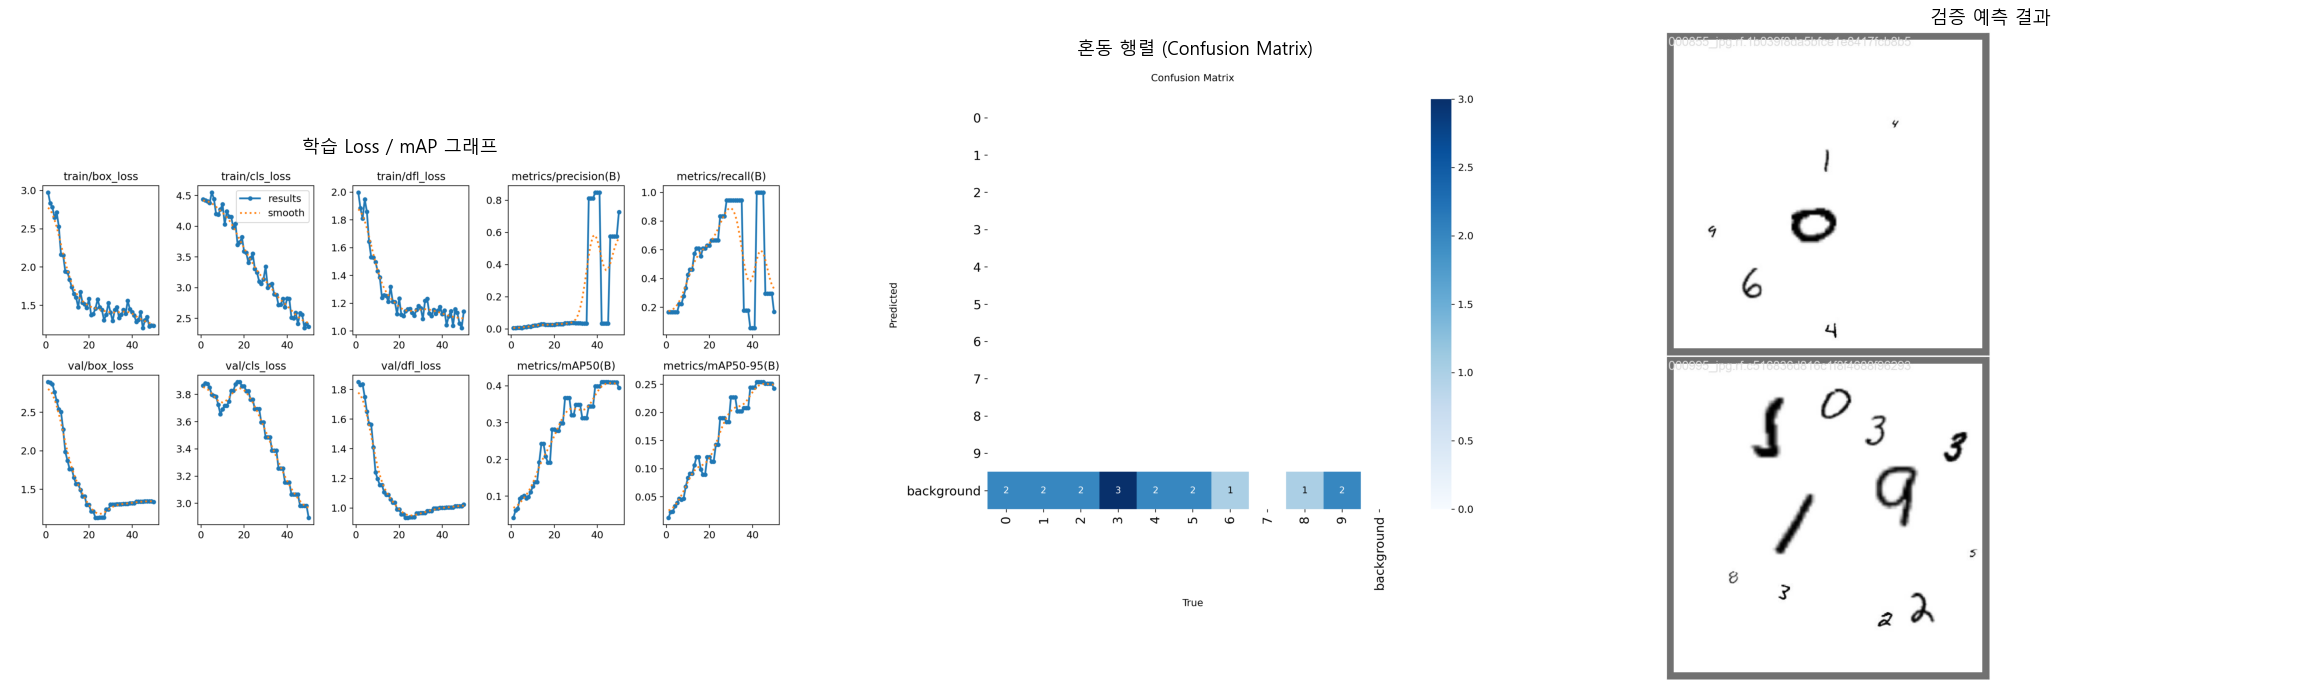

In [13]:
import matplotlib.font_manager as fm

# 한글 폰트 설정 (Windows)
font_path = 'C:/Windows/Fonts/malgun.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['axes.unicode_minus'] = False

# 학습 결과 이미지 확인 (실제 저장된 경로)
result_dir = 'C:/Users/Admin/runs/detect/runs/detect/mnist_numbers'

result_images = {
    'results.png': '학습 Loss / mAP 그래프',
    'confusion_matrix.png': '혼동 행렬 (Confusion Matrix)',
    'val_batch0_pred.jpg': '검증 예측 결과',
}

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for i, (fname, title) in enumerate(result_images.items()):
    fpath = os.path.join(result_dir, fname)
    if os.path.exists(fpath):
        img = cv2.imread(fpath)
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(title, fontsize=13)
    else:
        axes[i].set_title(f'{title} (파일 없음)')
        print(f"[!] {fpath} 없음")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


## 4단계: 모델 평가 (Validation)

In [14]:
# 학습된 best 모델 로드
best_model = YOLO('C:/Users/Admin/runs/detect/runs/detect/mnist_numbers/weights/best.pt')

# 검증 데이터로 평가
metrics = best_model.val(data="Mnist_numbers.v1i.yolov8/data.yaml", device=0)

print("\n=== 평가 결과 ===")
print(f"mAP50     : {metrics.box.map50:.4f}")
print(f"mAP50-95  : {metrics.box.map:.4f}")
print(f"Precision : {metrics.box.mp:.4f}")
print(f"Recall    : {metrics.box.mr:.4f}")


Ultralytics 8.4.31  Python-3.11.15 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 99.919.0 MB/s, size: 11.8 KB)
val: Scanning C:\Users\Admin\hipython\OBJDECT\Mnist_numbers.v1i.yolov8\valid\labels.cache... 2 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2/2  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.7s/it 1.7s
                   all          2         17      0.033          1      0.411      0.253
                     0          2          2     0.0345          1      0.828      0.599
                     1          2          2     0.0339          1      0.595      0.368
                     2          1          2     0.0317          1      0.578      0.347
                     3          1          3     0.0469          1      0.431      0.276
         

## 5단계: 새 이미지로 추론 (Predict)

테스트 이미지 수: 2

0: 640x640 (no detections), 21.7ms
1: 640x640 (no detections), 21.7ms
Speed: 3.3ms preprocess, 21.7ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\Admin\runs\detect\runs\detect\mnist_predict


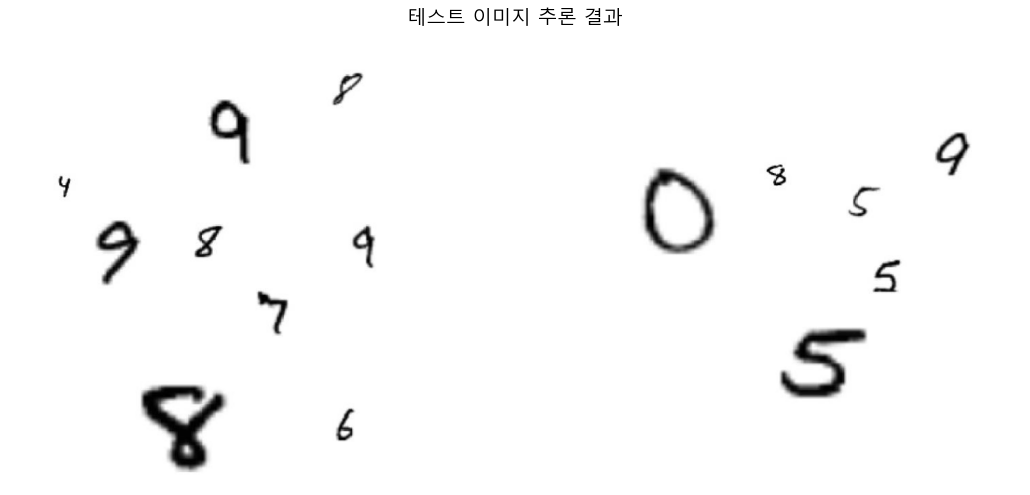

In [15]:
# 테스트 이미지로 추론
test_img_dir = data_config['test']
test_imgs = glob.glob(os.path.join(test_img_dir, '*.jpg'))
print(f"테스트 이미지 수: {len(test_imgs)}")

results = best_model.predict(
    source=test_imgs,
    conf=0.25,
    iou=0.45,
    device=0,
    save=True,
    project="C:/Users/Admin/runs/detect/runs/detect",
    name="mnist_predict",
    exist_ok=True
)

# 결과 시각화
fig, axes = plt.subplots(1, len(test_imgs), figsize=(12, 5))
if len(test_imgs) == 1:
    axes = [axes]

for i, r in enumerate(results):
    img_result = r.plot()
    axes[i].imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
    axes[i].axis('off')

    for box in r.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        print(f"탐지: 숫자 '{class_names[cls_id]}' (신뢰도: {conf:.4f})")

plt.suptitle('테스트 이미지 추론 결과', fontsize=14)
plt.tight_layout()
plt.show()


## 6단계: 실시간 웹캠 탐지

In [35]:
cap.release()
